데이터 기준일 : 2026-08-14
KOSPI        : 6,977.94
MA200        : 5,873.23
시장 상태    : 상승장

[매수 후보 TOP 20]


,Code,Name,Close,BuyScore,20일(%),6-1M(%),MA20이격(%),거래대금(억),유형,위험도,해석
0,475150,SK이터닉스,58300,79.81,12.12,135.84,5.25,4774.99,강한추세,높음,추세는 매우 강하지만 이미 많이 오른 종목
1,006340,대원전선,14710,73.93,20.28,256.38,8.69,2124.93,강한추세,높음,추세는 매우 강하지만 이미 많이 오른 종목
2,021240,코웨이,98200,72.02,1.55,15.86,4.93,167.48,균형형,낮음,추세와 과열 정도의 균형이 좋은 종목
3,010950,S-Oil,147600,66.05,1.86,40.96,8.35,558.10,일반,보통,무난한 상승 추세 종목
4,001800,오리온홀딩스,26800,57.82,2.88,13.97,2.79,20.98,저과열,낮음,과열은 적지만 상승 힘을 더 확인할 종목
5,417310,코람코더원리츠,10930,51.46,9.96,13.86,2.15,18.95,저과열,낮음,과열은 적지만 상승 힘을 더 확인할 종목
6,005430,한국공항,86200,50.74,0.58,27.30,0.80,14.63,균형형,낮음,추세와 과열 정도의 균형이 좋은 종목
7,003690,코리안리,15290,41.35,11.93,9.98,9.18,41.98,일반,보통,무난한 상승 추세 종목
8,089860,롯데렌탈,45000,27.95,22.45,4.78,12.16,64.36,급등주의,높음,최근 급등하여 추격매수 주의



[균형형 - TOP 10]


,Code,Name,Close,MA20,MA60,매수가,손절가,1R(30%매도),2R(30%매도),현재단계,매도신호
2,021240,코웨이,98200,93585.0,92142.0,98200.0,92142.0,104258.0,110317.0,1R 전,보유
6,005430,한국공항,86200,85515.0,82603.0,86200.0,82603.0,89797.0,93393.0,1R 전,보유


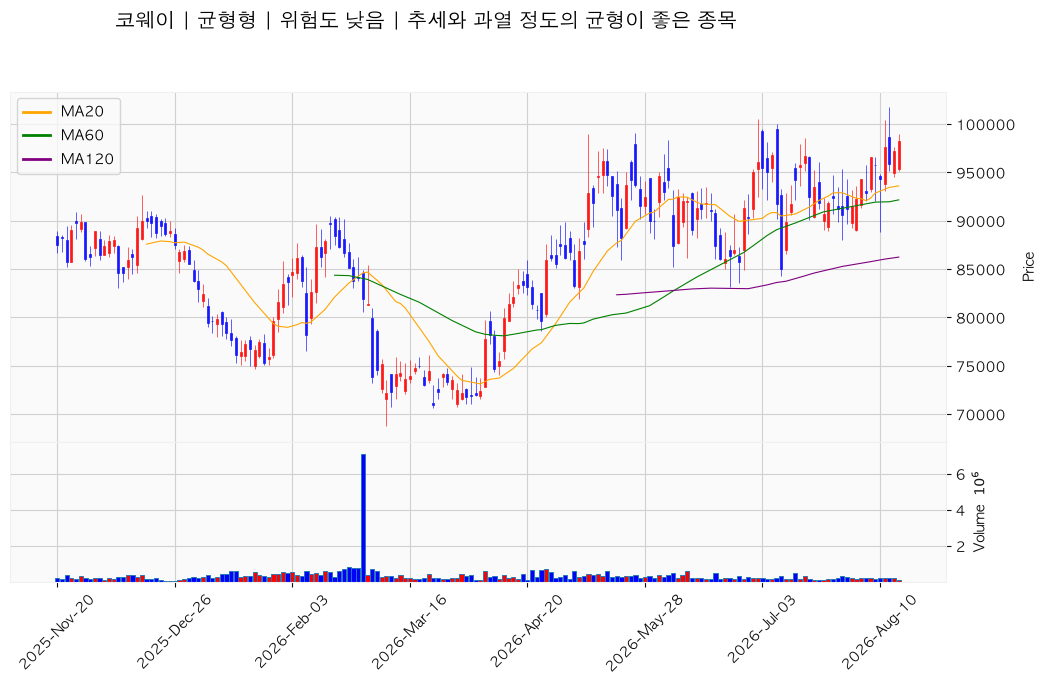

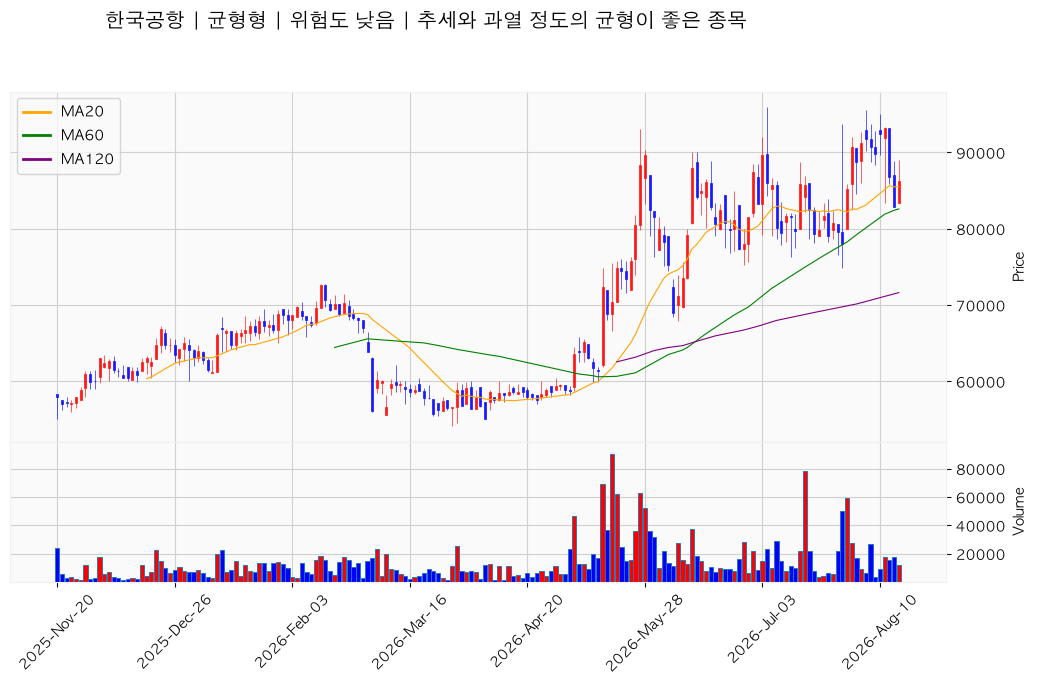

In [5]:
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
import mplfinance as mpf

from IPython.display import display


# ============================================================
# 1. 설정
# ============================================================

TOP_N = 20
CHART_N = 10

MIN_VALUE = 1_000_000_000    # 평균 거래대금 10억원
STOP_RATE = 0.08              # 최대 손실 8%

# 보고 싶은 유형
opt = '균형형'
# opt = '강한추세'
# opt = '급등주의'
# opt = '과열주의'
# opt = '저과열'
# opt = '일반'
# opt = '전체'

# 실제 매수 후 기록
BUY_PRICE = {}                # 예: {'021240': 98200}
BUY_STOP = {}                 # 예: {'021240': 92100}

CACHE = Path('stock_cache')


# ============================================================
# 2. 한글 폰트
# ============================================================

os_name = platform.system()

if os_name == 'Windows':
    font = 'Malgun Gothic'
elif os_name == 'Darwin':
    font = 'AppleGothic'
else:
    font = 'NanumGothic'

available_fonts = {f.name for f in fm.fontManager.ttflist}

if font not in available_fonts:
    font = 'DejaVu Sans'

plt.rcParams.update({
    'font.family': font,
    'axes.unicode_minus': False,
    'figure.titleweight': 'normal'
})


# ============================================================
# 3. KOSPI 시장 상태
# ============================================================

kospi = pd.read_csv(
    CACHE / 'KS11.csv',
    index_col='Date',
    parse_dates=['Date']
)

close = kospi['Close']

kospi_now = close.iloc[-1]
ma200 = close.rolling(200).mean().iloc[-1]

market_up = kospi_now > ma200
market_date = kospi.index[-1].date()

print(f'데이터 기준일 : {market_date}')
print(f'KOSPI        : {kospi_now:,.2f}')
print(f'MA200        : {ma200:,.2f}')
print('시장 상태    :', '상승장' if market_up else '하락장')


# ============================================================
# 4. KOSPI 종목 목록
# ============================================================

stocks = pd.read_csv(CACHE / 'KOSPI_list.csv')

code_col = 'Code' if 'Code' in stocks.columns else 'Symbol'

stocks[code_col] = (
    stocks[code_col]
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.zfill(6)
)

# 우선주 제외
stocks = stocks[
    ~stocks['Name'].str.contains(
        r'\d*우[A-Z]?$',
        regex=True,
        na=False
    )
].copy()


# ============================================================
# 5. 전체 종목 분석
# ============================================================

rows = []

for _, stock in stocks.iterrows():

    code = stock[code_col]
    name = stock['Name']

    stock_file = CACHE / f'{code}.csv'

    if not stock_file.exists():
        continue

    try:
        df = pd.read_csv(
            stock_file,
            index_col='Date',
            parse_dates=['Date']
        )

        if len(df) < 130:
            continue

        # ----------------------------------------------------
        # 이동평균선
        # ----------------------------------------------------

        close = df['Close']

        ma20 = close.rolling(20).mean()
        ma60 = close.rolling(60).mean()
        ma120 = close.rolling(120).mean()


        # ----------------------------------------------------
        # 상승 정배열
        # 현재가 > MA20 > MA60 > MA120
        # ----------------------------------------------------

        trend = (
            close.iloc[-1]
            > ma20.iloc[-1]
            > ma60.iloc[-1]
            > ma120.iloc[-1]
        )


        # ----------------------------------------------------
        # 이동평균선 상승
        # ----------------------------------------------------

        rising = (
            ma20.iloc[-1] > ma20.iloc[-6]
            and ma60.iloc[-1] > ma60.iloc[-6]
            and ma120.iloc[-1] > ma120.iloc[-6]
        )

        if not (trend and rising):
            continue


        # ----------------------------------------------------
        # 투자 지표
        # ----------------------------------------------------

        ret = close.pct_change()

        # 최근 20일 수익률
        r20 = close.iloc[-1] / close.iloc[-21] - 1

        # 6개월 - 최근 1개월 모멘텀
        momentum = close.iloc[-22] / close.iloc[-126] - 1

        # MA20 이격도
        distance = close.iloc[-1] / ma20.iloc[-1] - 1

        # 최근 20일 평균 거래대금
        value = (close * df['Volume']).tail(20).mean()

        # 최근 20일 변동성
        volatility = ret.tail(20).std()

        # 최근 5일 최대 하루 상승률
        max_up = ret.tail(5).max()


        # ----------------------------------------------------
        # 추가 조건
        # ----------------------------------------------------

        condition = (
            value >= MIN_VALUE
            and momentum > 0
            and r20 <= 0.30
            and distance <= 0.15
            and max_up <= 0.20
        )

        if not condition:
            continue


        # ----------------------------------------------------
        # 결과 저장
        # ----------------------------------------------------

        rows.append([
            code,
            name,
            close.iloc[-1],
            ma20.iloc[-1],
            ma60.iloc[-1],
            r20,
            momentum,
            distance,
            value,
            volatility
        ])

    except Exception as e:
        print(f'{code} {name} 오류 : {e}')


# ============================================================
# 6. 결과 DataFrame
# ============================================================

cols = [
    'Code',
    'Name',
    'Close',
    'MA20',
    'MA60',
    'Return20',
    'Momentum',
    'Distance',
    'Value',
    'Volatility'
]

result = pd.DataFrame(rows, columns=cols)


if result.empty:

    print('\n조건을 만족하는 종목이 없습니다.')

else:

    # ========================================================
    # 7. 매수 점수
    # ========================================================

    # 모멘텀 40점
    result['모멘텀점수'] = result['Momentum'].rank(pct=True) * 40

    # MA20 이격도 30점
    # +5% 부근에서 가장 높은 점수
    result['이격점수'] = (
        30 * (1 - abs(result['Distance'] - 0.05) / 0.10)
    ).clip(0, 30)

    # 유동성 15점
    result['유동성점수'] = result['Value'].rank(pct=True) * 15

    # 안정성 15점
    result['안정성점수'] = (
        1 - result['Volatility'].rank(pct=True)
    ) * 15

    # 총점
    result['BuyScore'] = (
        result['모멘텀점수']
        + result['이격점수']
        + result['유동성점수']
        + result['안정성점수']
    )

    result = (
        result
        .sort_values('BuyScore', ascending=False)
        .reset_index(drop=True)
    )


    # ========================================================
    # 8. 유형 분류
    # ========================================================

    m = result['Momentum'] * 100
    r20 = result['Return20'] * 100
    dist = result['Distance'] * 100

    conditions = [
        m >= 80,
        r20 >= 20,
        dist >= 10,
        (m >= 15) & (m <= 50) & (r20 <= 5) & (dist <= 6),
        dist <= 3
    ]

    result['유형'] = np.select(
        conditions,
        [
            '강한추세',
            '급등주의',
            '과열주의',
            '균형형',
            '저과열'
        ],
        default='일반'
    )


    # ========================================================
    # 9. 위험도 / 해석
    # ========================================================

    result['위험도'] = result['유형'].map({
        '강한추세': '높음',
        '급등주의': '높음',
        '과열주의': '높음',
        '균형형': '낮음',
        '저과열': '낮음',
        '일반': '보통'
    })

    result['해석'] = result['유형'].map({
        '강한추세': '추세는 매우 강하지만 이미 많이 오른 종목',
        '급등주의': '최근 급등하여 추격매수 주의',
        '과열주의': '상승 추세지만 MA20에서 다소 멀어진 상태',
        '균형형': '추세와 과열 정도의 균형이 좋은 종목',
        '저과열': '과열은 적지만 상승 힘을 더 확인할 종목',
        '일반': '무난한 상승 추세 종목'
    })


    # ========================================================
    # 10. 화면 표시용 단위
    # ========================================================

    result['20일(%)'] = result['Return20'] * 100
    result['6-1M(%)'] = result['Momentum'] * 100
    result['MA20이격(%)'] = result['Distance'] * 100
    result['거래대금(억)'] = result['Value'] / 1e8


    # ========================================================
    # 11. 전체 매수 후보
    # ========================================================

    if market_up:
        print(f'\n[매수 후보 TOP {TOP_N}]')
    else:
        print(f'\n[관심 종목 TOP {TOP_N} - KOSPI MA200 하회]')

    display(
        result[[
            'Code',
            'Name',
            'Close',
            'BuyScore',
            '20일(%)',
            '6-1M(%)',
            'MA20이격(%)',
            '거래대금(억)',
            '유형',
            '위험도',
            '해석'
        ]]
        .head(TOP_N)
        .round(2)
    )


    # ========================================================
    # 12. 원하는 유형 선택
    # ========================================================

    if opt == '전체':
        selected = result.head(CHART_N).copy()
    else:
        selected = (
            result[result['유형'] == opt]
            .head(CHART_N)
            .copy()
        )

    print(f'\n[{opt} - TOP {CHART_N}]')


    if selected.empty:

        print('해당 유형의 종목이 없습니다.')

    else:

        # ====================================================
        # 13. 매수가
        # ====================================================

        selected['매수가'] = (
            selected['Code']
            .map(BUY_PRICE)
            .fillna(selected['Close'])
        )


        # ====================================================
        # 14. 손절가
        # MA60 또는 매수가 -8% 중 높은 가격
        # ====================================================

        auto_stop = pd.concat(
            [
                selected['MA60'],
                selected['매수가'] * (1 - STOP_RATE)
            ],
            axis=1
        ).max(axis=1)

        selected['손절가'] = (
            selected['Code']
            .map(BUY_STOP)
            .fillna(auto_stop)
        )


        # ====================================================
        # 15. R / 분할매도
        # ====================================================

        selected['R'] = (
            selected['매수가']
            - selected['손절가']
        )

        selected['1R(30%매도)'] = (
            selected['매수가']
            + selected['R']
        )

        selected['2R(30%매도)'] = (
            selected['매수가']
            + selected['R'] * 2
        )


        # ====================================================
        # 16. 현재 매도 단계
        # ====================================================

        price = selected['Close']

        sell_conditions = [
            price <= selected['손절가'],
            price < selected['MA60'],
            price < selected['MA20'],
            price >= selected['2R(30%매도)'],
            price >= selected['1R(30%매도)']
        ]

        selected['현재단계'] = np.select(
            sell_conditions,
            [
                '손절 구간',
                '추세 이탈',
                'MA20 이탈',
                '2R 이상',
                '1R 이상'
            ],
            default='1R 전'
        )

        selected['매도신호'] = np.select(
            sell_conditions,
            [
                '전량 손절',
                '매도',
                '주의',
                '30% 매도 → 남은 40% MA20 추적',
                '30% 매도'
            ],
            default='보유'
        )


        # ====================================================
        # 17. 매수 / 매도 계획
        # ====================================================

        display(
            selected[[
                'Code',
                'Name',
                'Close',
                'MA20',
                'MA60',
                '매수가',
                '손절가',
                '1R(30%매도)',
                '2R(30%매도)',
                '현재단계',
                '매도신호'
            ]]
            .round(0)
        )


        # ====================================================
        # 18. 캔들 차트 설정
        # ====================================================

        # 한국식 캔들 색상
        colors = mpf.make_marketcolors(
            up='red',
            down='blue',
            inherit=True
        )

        # 이동평균선 색상
        # MA20  = orange
        # MA60  = green
        # MA120 = purple
        style = mpf.make_mpf_style(
            base_mpf_style='yahoo',
            marketcolors=colors,
            mavcolors=['orange', 'green', 'purple'],
            rc={
                'font.family': font,
                'figure.titleweight': 'normal'
            }
        )


        # ====================================================
        # 19. 이동평균선 범례
        # ====================================================

        ma_legend = [
            Line2D([0], [0], color='orange', lw=2, label='MA20'),
            Line2D([0], [0], color='green', lw=2, label='MA60'),
            Line2D([0], [0], color='purple', lw=2, label='MA120')
        ]


        # ====================================================
        # 20. 캔들 차트
        # ====================================================

        for _, row in selected.iterrows():

            stock_file = CACHE / f"{row['Code']}.csv"

            df = pd.read_csv(
                stock_file,
                index_col='Date',
                parse_dates=['Date']
            )

            title = (
                f"{row['Name']} | "
                f"{row['유형']} | "
                f"위험도 {row['위험도']} | "
                f"{row['해석']}"
            )


            # returnfig=True를 사용하면
            # matplotlib의 fig, axes를 받을 수 있음
            fig, axes = mpf.plot(
                df.tail(180),
                type='candle',
                mav=(20, 60, 120),
                volume=True,
                style=style,
                figsize=(13, 7),
                title=title,
                returnfig=True
            )


            # 가격 차트는 axes[0]
            ax = axes[0]

            # MA20 / MA60 / MA120 범례 추가
            ax.legend(
                handles=ma_legend,
                loc='upper left',
                frameon=True
            )

            plt.show()
            plt.close(fig)

데이터 기준일 : 2026-08-14
KOSPI        : 6,977.94
MA200        : 5,873.23
시장 상태    : 상승장

[매수 후보 TOP 20]


,Code,Name,Close,BuyScore,20일(%),6-1M(%),MA20이격(%),거래대금(억),유형,위험도,해석
0,475150,SK이터닉스,58300,79.81,12.12,135.84,5.25,4774.99,강한추세,높음,추세는 매우 강하지만 이미 많이 오른 종목
1,006340,대원전선,14710,73.93,20.28,256.38,8.69,2124.93,강한추세,높음,추세는 매우 강하지만 이미 많이 오른 종목
2,021240,코웨이,98200,72.02,1.55,15.86,4.93,167.48,균형형,낮음,추세와 과열 정도의 균형이 좋은 종목
3,010950,S-Oil,147600,66.05,1.86,40.96,8.35,558.10,일반,보통,무난한 상승 추세 종목
4,001800,오리온홀딩스,26800,57.82,2.88,13.97,2.79,20.98,저과열,낮음,과열은 적지만 상승 힘을 더 확인할 종목
5,417310,코람코더원리츠,10930,51.46,9.96,13.86,2.15,18.95,저과열,낮음,과열은 적지만 상승 힘을 더 확인할 종목
6,005430,한국공항,86200,50.74,0.58,27.30,0.80,14.63,균형형,낮음,추세와 과열 정도의 균형이 좋은 종목
7,003690,코리안리,15290,41.35,11.93,9.98,9.18,41.98,일반,보통,무난한 상승 추세 종목
8,089860,롯데렌탈,45000,27.95,22.45,4.78,12.16,64.36,급등주의,높음,최근 급등하여 추격매수 주의



[균형형 - TOP 10]


,Code,Name,Close,MA20,MA60,매수가,손절가,1R(30%매도),2R(30%매도),현재단계,매도신호
2,021240,코웨이,98200,93585.0,92142.0,98200.0,92142.0,104258.0,110317.0,1R 전,보유
6,005430,한국공항,86200,85515.0,82603.0,86200.0,82603.0,89797.0,93393.0,1R 전,보유


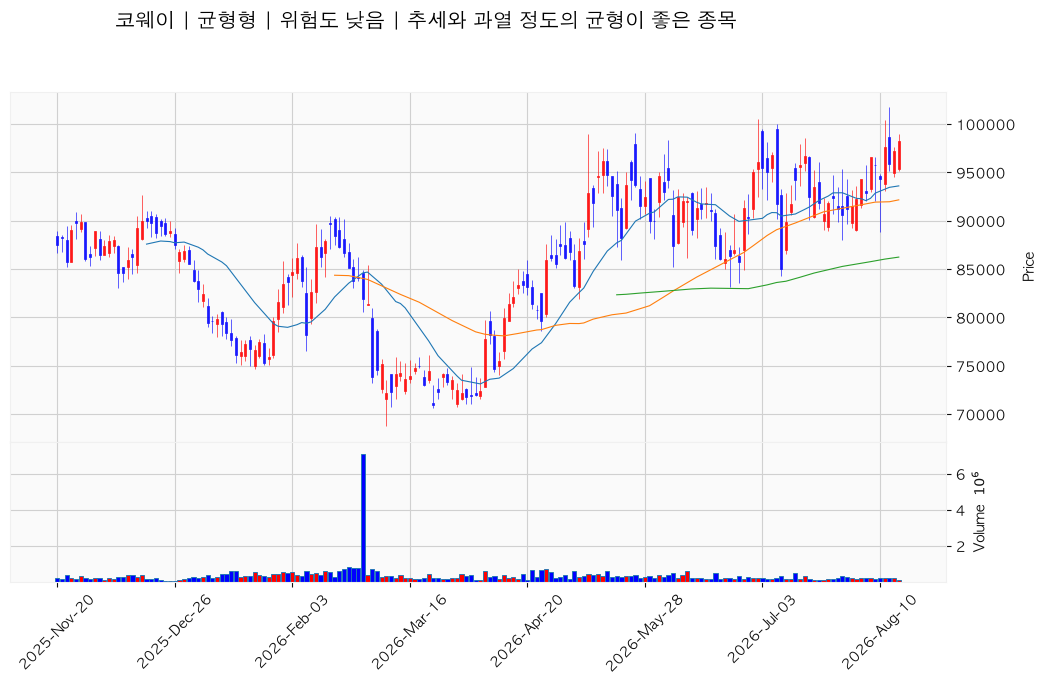

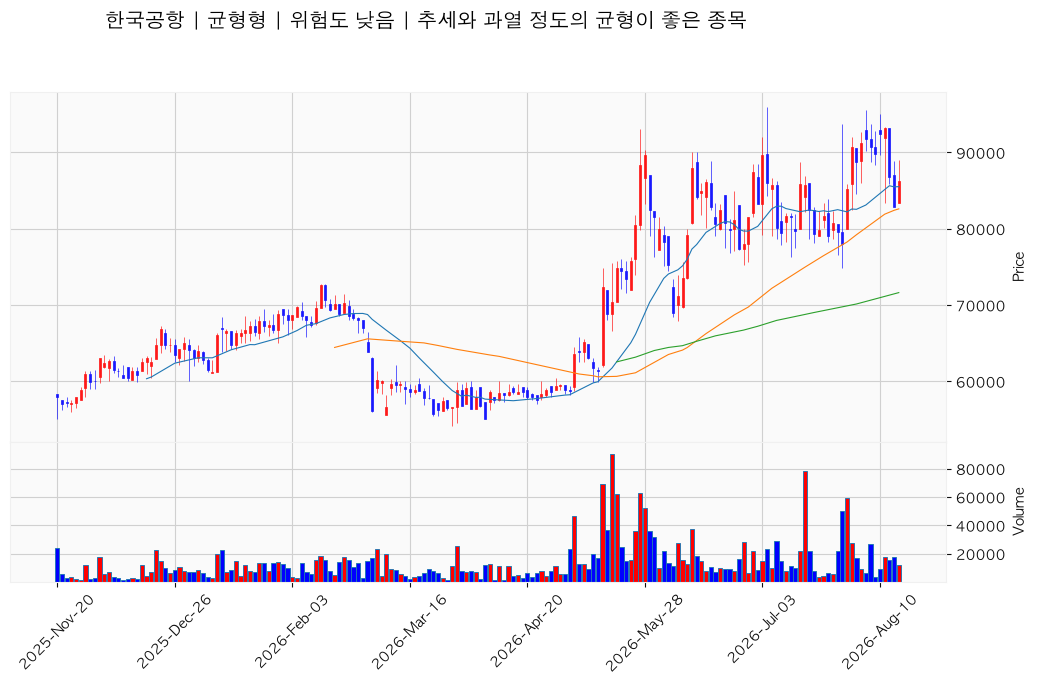

In [4]:
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import mplfinance as mpf

from IPython.display import display
from pathlib import Path


# 1. 설정
TOP_N = 20
CHART_N = 10
MIN_VALUE = 1_000_000_000       # 평균 거래대금 10억원
STOP_RATE = 0.08                 # 최대 손실 8%

# 보고 싶은 유형
opt = '균형형'
# opt = '강한추세'
# opt = '급등주의'
# opt = '과열주의'
# opt = '저과열'
# opt = '일반'
# opt = '전체'

# 실제 매수 후 기록
BUY_PRICE = {}                   # 예: {'021240': 98200}
BUY_STOP = {}                    # 예: {'021240': 92100}

CACHE = Path('stock_cache')


# 2. 한글 폰트
os_name = platform.system()

if os_name == 'Windows':
    font = 'Malgun Gothic'
elif os_name == 'Darwin':
    font = 'AppleGothic'
else:
    font = 'NanumGothic'

# 해당 폰트가 없으면 대체
available_fonts = {f.name for f in fm.fontManager.ttflist}

if font not in available_fonts:
    font = 'DejaVu Sans'

plt.rcParams.update({
    'font.family': font,
    'figure.titleweight': 'normal',
    'axes.unicode_minus': False
})


# 3. KOSPI 시장 상태
kospi = pd.read_csv(
    CACHE / 'KS11.csv',
    index_col='Date',
    parse_dates=['Date']
)

c = kospi['Close']

kospi_now = c.iloc[-1]
ma200 = c.rolling(200).mean().iloc[-1]
market_up = kospi_now > ma200
market_date = kospi.index[-1].date()

print(f'데이터 기준일 : {market_date}')
print(f'KOSPI        : {kospi_now:,.2f}')
print(f'MA200        : {ma200:,.2f}')
print('시장 상태    :', '상승장' if market_up else '하락장')


# 4. KOSPI 종목 목록
stocks = pd.read_csv(CACHE / 'KOSPI_list.csv')

code_col = 'Code' if 'Code' in stocks.columns else 'Symbol'

stocks[code_col] = (
    stocks[code_col].astype(str)
    .str.replace('.0', '', regex=False)
    .str.zfill(6)
)

# 우선주 다시 한번 제외
stocks = stocks[
    ~stocks['Name'].str.contains(
        r'\d*우[A-Z]?$',
        regex=True,
        na=False
    )
].copy()


# 5. 전체 종목 분석
rows = []

for _, stock in stocks.iterrows():

    code = stock[code_col]
    name = stock['Name']
    stock_file = CACHE / f'{code}.csv'

    # 주가 파일이 없으면 제외
    if not stock_file.exists():
        continue

    try:
        df = pd.read_csv(
            stock_file,
            index_col='Date',
            parse_dates=['Date']
        )

        if len(df) < 130:
            continue


        # 이동평균선
        c = df['Close']

        ma20 = c.rolling(20).mean()
        ma60 = c.rolling(60).mean()
        ma120 = c.rolling(120).mean()


        # 상승 추세
        trend = (
            c.iloc[-1] >
            ma20.iloc[-1] >
            ma60.iloc[-1] >
            ma120.iloc[-1]
        )

        rising = (
            ma20.iloc[-1] > ma20.iloc[-6] and
            ma60.iloc[-1] > ma60.iloc[-6] and
            ma120.iloc[-1] > ma120.iloc[-6]
        )

        if not (trend and rising):
            continue


        # 투자 지표
        ret = c.pct_change()

        r20 = c.iloc[-1] / c.iloc[-21] - 1
        momentum = c.iloc[-22] / c.iloc[-126] - 1
        distance = c.iloc[-1] / ma20.iloc[-1] - 1

        value = (c * df['Volume']).tail(20).mean()
        volatility = ret.tail(20).std()
        max_up = ret.tail(5).max()


        # 추가 조건
        condition = (
            value >= MIN_VALUE and
            momentum > 0 and
            r20 <= 0.30 and
            distance <= 0.15 and
            max_up <= 0.20
        )

        if not condition:
            continue


        # 결과 저장
        rows.append([
            code,
            name,
            c.iloc[-1],
            ma20.iloc[-1],
            ma60.iloc[-1],
            r20,
            momentum,
            distance,
            value,
            volatility
        ])


    except Exception as e:
        print(f'{code} {name} 오류 : {e}')


# 6. 결과
cols = [
    'Code', 'Name', 'Close',
    'MA20', 'MA60',
    'Return20', 'Momentum',
    'Distance', 'Value', 'Volatility'
]

result = pd.DataFrame(rows, columns=cols)


if result.empty:

    print('\n조건을 만족하는 종목이 없습니다.')

else:

    # 7. 매수 점수
    result['모멘텀점수'] = (
        result['Momentum'].rank(pct=True) * 40
    )

    result['이격점수'] = (
        30 * (1 - abs(result['Distance'] - 0.05) / 0.10)
    ).clip(0, 30)

    result['유동성점수'] = (
        result['Value'].rank(pct=True) * 15
    )

    result['안정성점수'] = (
        1 - result['Volatility'].rank(pct=True)
    ) * 15

    result['BuyScore'] = (
        result['모멘텀점수'] +
        result['이격점수'] +
        result['유동성점수'] +
        result['안정성점수']
    )

    result = (
        result
        .sort_values('BuyScore', ascending=False)
        .reset_index(drop=True)
    )


    # 8. 유형 분류
    m = result['Momentum'] * 100
    r20 = result['Return20'] * 100
    dist = result['Distance'] * 100

    conditions = [
        m >= 80,
        r20 >= 20,
        dist >= 10,
        (m >= 15) & (m <= 50) & (r20 <= 5) & (dist <= 6),
        dist <= 3
    ]

    result['유형'] = np.select(
        conditions,
        [
            '강한추세',
            '급등주의',
            '과열주의',
            '균형형',
            '저과열'
        ],
        default='일반'
    )


    # 9. 위험도 / 해석
    result['위험도'] = result['유형'].map({
        '강한추세': '높음',
        '급등주의': '높음',
        '과열주의': '높음',
        '균형형': '낮음',
        '저과열': '낮음',
        '일반': '보통'
    })

    result['해석'] = result['유형'].map({
        '강한추세': '추세는 매우 강하지만 이미 많이 오른 종목',
        '급등주의': '최근 급등하여 추격매수 주의',
        '과열주의': '상승 추세지만 MA20에서 다소 멀어진 상태',
        '균형형': '추세와 과열 정도의 균형이 좋은 종목',
        '저과열': '과열은 적지만 상승 힘을 더 확인할 종목',
        '일반': '무난한 상승 추세 종목'
    })


    # 10. 보기 좋은 단위
    result['20일(%)'] = result['Return20'] * 100
    result['6-1M(%)'] = result['Momentum'] * 100
    result['MA20이격(%)'] = result['Distance'] * 100
    result['거래대금(억)'] = result['Value'] / 1e8


    # 11. 전체 매수 후보
    print(
        '\n[매수 후보 TOP 20]'
        if market_up
        else '\n[관심 종목 TOP 20 - KOSPI MA200 하회]'
    )

    display(
        result[[
            'Code',
            'Name',
            'Close',
            'BuyScore',
            '20일(%)',
            '6-1M(%)',
            'MA20이격(%)',
            '거래대금(억)',
            '유형',
            '위험도',
            '해석'
        ]]
        .head(TOP_N)
        .round(2)
    )


    # 12. 원하는 유형 선택
    if opt == '전체':

        selected = result.head(CHART_N).copy()

    else:

        selected = (
            result[result['유형'] == opt]
            .head(CHART_N)
            .copy()
        )


    print(f'\n[{opt} - TOP {CHART_N}]')


    if selected.empty:

        print('해당 유형의 종목이 없습니다.')

    else:

        # 13. 매수가
        selected['매수가'] = (
            selected['Code']
            .map(BUY_PRICE)
            .fillna(selected['Close'])
        )


        # 자동 손절가
        # MA60 또는 매수가 -8% 중 높은 가격
        auto_stop = pd.concat([
            selected['MA60'],
            selected['매수가'] * (1 - STOP_RATE)
        ], axis=1).max(axis=1)


        # 직접 입력한 손절가가 있으면 우선 사용
        selected['손절가'] = (
            selected['Code']
            .map(BUY_STOP)
            .fillna(auto_stop)
        )


        # 14. R / 분할매도
        selected['R'] = (
            selected['매수가'] -
            selected['손절가']
        )

        selected['1R(30%매도)'] = (
            selected['매수가'] +
            selected['R']
        )

        selected['2R(30%매도)'] = (
            selected['매수가'] +
            selected['R'] * 2
        )


        # 15. 현재 매도 단계
        price = selected['Close']

        sell_conditions = [
            price <= selected['손절가'],
            price < selected['MA60'],
            price < selected['MA20'],
            price >= selected['2R(30%매도)'],
            price >= selected['1R(30%매도)']
        ]

        selected['현재단계'] = np.select(
            sell_conditions,
            [
                '손절 구간',
                '추세 이탈',
                'MA20 이탈',
                '2R 이상',
                '1R 이상'
            ],
            default='1R 전'
        )

        selected['매도신호'] = np.select(
            sell_conditions,
            [
                '전량 손절',
                '매도',
                '주의',
                '30% 매도 → 남은 40% MA20 추적',
                '30% 매도'
            ],
            default='보유'
        )


        # 16. 매수 / 매도 계획
        display(
            selected[[
                'Code',
                'Name',
                'Close',
                'MA20',
                'MA60',
                '매수가',
                '손절가',
                '1R(30%매도)',
                '2R(30%매도)',
                '현재단계',
                '매도신호'
            ]]
            .round(0)
        )


        # 17. 캔들 차트
        colors = mpf.make_marketcolors(
            up='red',
            down='blue',
            inherit=True
        )


        style = mpf.make_mpf_style(
            base_mpf_style='yahoo',
            marketcolors=colors,
            rc={
                'font.family': font,
                'figure.titleweight': 'normal'
            }
        )


        for _, row in selected.iterrows():

            stock_file = CACHE / f"{row['Code']}.csv"

            df = pd.read_csv(
                stock_file,
                index_col='Date',
                parse_dates=['Date']
            )

            title = (
                f"{row['Name']} | "
                f"{row['유형']} | "
                f"위험도 {row['위험도']} | "
                f"{row['해석']}"
            )

            mpf.plot(
                df.tail(180),
                type='candle',
                mav=(20, 60, 120),
                volume=True,
                style=style,
                figsize=(13, 7),
                title=title
            )

In [2]:
# end